In [21]:
import keras

from keras import Sequential
from keras import layers
import matplotlib.pyplot as plt
import numpy as np

In [26]:
batch_size = 32 # number of images in each batch
img_size = (32, 32) # 32 x 32 pixel images in input data

train_dataset, validation_dataset = keras.utils.image_dataset_from_directory(
    '../../CIFAR-10-images/train',
    batch_size=batch_size,
    image_size=img_size,
    label_mode='categorical',
    validation_split=0.2,
    subset='both',
    seed=123)

test_dataset = keras.utils.image_dataset_from_directory(
    '../../CIFAR-10-images/test',
    batch_size=batch_size,
    image_size=img_size,
    label_mode='categorical')

Found 50000 files belonging to 10 classes.
Using 40000 files for training.
Using 10000 files for validation.
Found 10000 files belonging to 10 classes.


In [27]:
inputs = keras.Input(shape=(32, 32, 3))

x = layers.Rescaling(1./255)(inputs)

x = layers.Conv2D(32, (3, 3), activation='relu')(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(64, (3, 3), activation='relu')(x)
x =layers.MaxPooling2D((2, 2))(x)

x = layers.Flatten()(x)

x = layers.Dense(64, activation='relu')(x)

outputs = layers.Dense(10, activation='softmax')(x)

model = keras.Model(inputs=inputs, outputs=outputs , name="cifar-10_CNN")

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'])

model.summary()

Model: "cifar-10_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10,
    verbose=1)

Epoch 1/10


I0000 00:00:1774019241.093696  127685 service.cc:153] XLA service 0x727590032b30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774019241.093755  127685 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3080, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1774019241.162254  127685 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1774019241.325226  127685 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1774019241.340700  127685 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2007__.34
I0000 00:00:1774019243.257605  127685 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


   6/1250 ━━━━━━━━━━━━━━━━━━━━ 32s 26ms/step - accuracy: 0.1069 - loss: 2.3415

I0000 00:00:1774019245.737831  127685 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 33s 22ms/step - accuracy: 0.4555 - loss: 1.5045 - val_accuracy: 0.5542 - val_loss: 1.2602
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.5908 - loss: 1.1683 - val_accuracy: 0.6205 - val_loss: 1.1026
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.6395 - loss: 1.0326 - val_accuracy: 0.6377 - val_loss: 1.0500
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.6727 - loss: 0.9429 - val_accuracy: 0.6520 - val_loss: 1.0035
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.6951 - loss: 0.8715 - val_accuracy: 0.6619 - val_loss: 0.9929
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.7169 - loss: 0.8115 - val_accuracy: 0.6669 - val_loss: 0.9851
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.7338 - loss: 0.7609 - val_accuracy: 0.6649 - val_loss: 1.0045
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.7536 - loss: 0.71

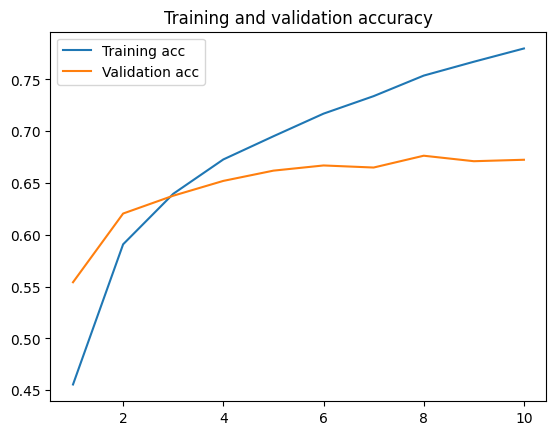

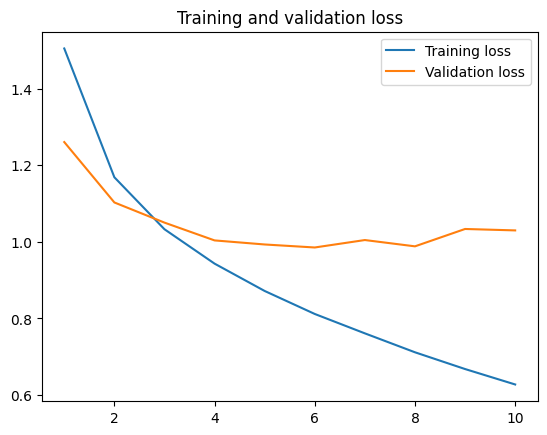

In [17]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc)+1)

plt.plot(epochs, acc, label='Training acc')
plt.plot(epochs, val_acc, label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [18]:
test_loss, test_acc = model.evaluate(test_dataset)
print(f'Test accuracy: {test_acc:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6675 - loss: 1.0301
Test accuracy: 0.6675
